## Data Loading

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    recall_score, precision_score
)

url = "https://raw.githubusercontent.com/steviep42/bios_534/refs/heads/main/data/alz_selected_20_features.csv"
alz = pd.read_csv(url)

# Take a look
alz.head()

,Eotaxin_3,FAS,Fibrinogen,GRO_alpha,Gamma_Interferon_induced_Monokin,IGF_BP_2,MIF,MMP10,MMP7,NT_proBNP,...,Pancreatic_polypeptide,Resistin,TNF_RII,TRAIL_R3,Thymus_Expressed_Chemokine_TECK,age,tau,p_tau,Ab_42,diagnosis
0,53,-0.083382,-7.035589,1.381830,2.949822,5.609472,-1.237874,-3.270169,-3.773503,4.553877,...,0.578781,-16.475315,-0.061875,-0.182900,4.149327,0.987624,6.297754,4.348108,12.019678,Control
1,62,-0.527633,-8.047190,1.372438,2.721793,5.347108,-1.897120,-3.649659,-5.968191,4.219508,...,0.336472,-16.025283,-0.328504,-0.500747,3.810182,0.986150,6.659294,4.859967,11.015759,Control
2,62,-0.634878,-7.195437,1.412679,2.762231,5.181784,-2.302585,-2.733368,-4.030227,4.248495,...,-0.891598,-16.475315,-0.415515,-0.924034,2.791992,0.986667,6.270988,4.400247,12.302271,Control
3,44,-0.478036,-7.799353,1.372438,2.885476,5.424950,-1.660731,-4.074542,-6.856149,4.110874,...,-0.820981,-13.501240,-0.342490,-0.384859,4.037285,0.986702,6.152733,4.494886,12.398138,Control
4,64,-0.127833,-6.980326,1.398431,2.851987,5.420535,-1.897120,-2.617296,-0.222222,4.465908,...,0.262364,-11.092838,-0.342490,-0.858259,4.534163,0.987163,6.623707,4.524589,11.024109,Control


In [34]:
print("Shape:", alz.shape, "\n")

# How many Impaired cases vs Control (non-impaired)
print(alz['diagnosis'].value_counts())

Shape: (333, 21) 

diagnosis
Control     242
Impaired     91
Name: count, dtype: int64


## Question 1

### Question 1.1

In [51]:
numeric_df = alz.drop(columns=['diagnosis'])
corr_matrix = numeric_df.corr()

print(corr_matrix)

# Filter: keep only pairs where |correlation| > 0.65
# Replace values that don't meet threshold with NaN so they appear blank in heatmap
filtered_corr = corr_matrix.where(corr_matrix.abs() > 0.65)

# Also zero out the diagonal (self-correlations = 1.0, not informative)
np.fill_diagonal(filtered_corr.values, np.nan)

print("Filtered correlation matrix (|r| > 0.65):")
print(filtered_corr.dropna(how='all').dropna(axis=1, how='all'))

                                  Eotaxin_3       FAS  Fibrinogen  GRO_alpha  \
Eotaxin_3                          1.000000  0.572353    0.364023   0.264721   
FAS                                0.572353  1.000000    0.354012   0.337910   
Fibrinogen                         0.364023  0.354012    1.000000   0.270438   
GRO_alpha                          0.264721  0.337910    0.270438   1.000000   
Gamma_Interferon_induced_Monokin   0.339290  0.395660    0.422711   0.356271   
IGF_BP_2                           0.707117  0.527154    0.391116   0.250300   
MIF                                0.398195  0.558238    0.143435   0.341842   
MMP10                              0.413654  0.500926    0.374598   0.395566   
MMP7                               0.375912  0.393121    0.398530   0.344491   
NT_proBNP                          0.284356  0.252289    0.237264   0.265404   
PAI_1                              0.405687  0.402750    0.395338   0.434601   
Pancreatic_polypeptide             0.210

### Question 1.2

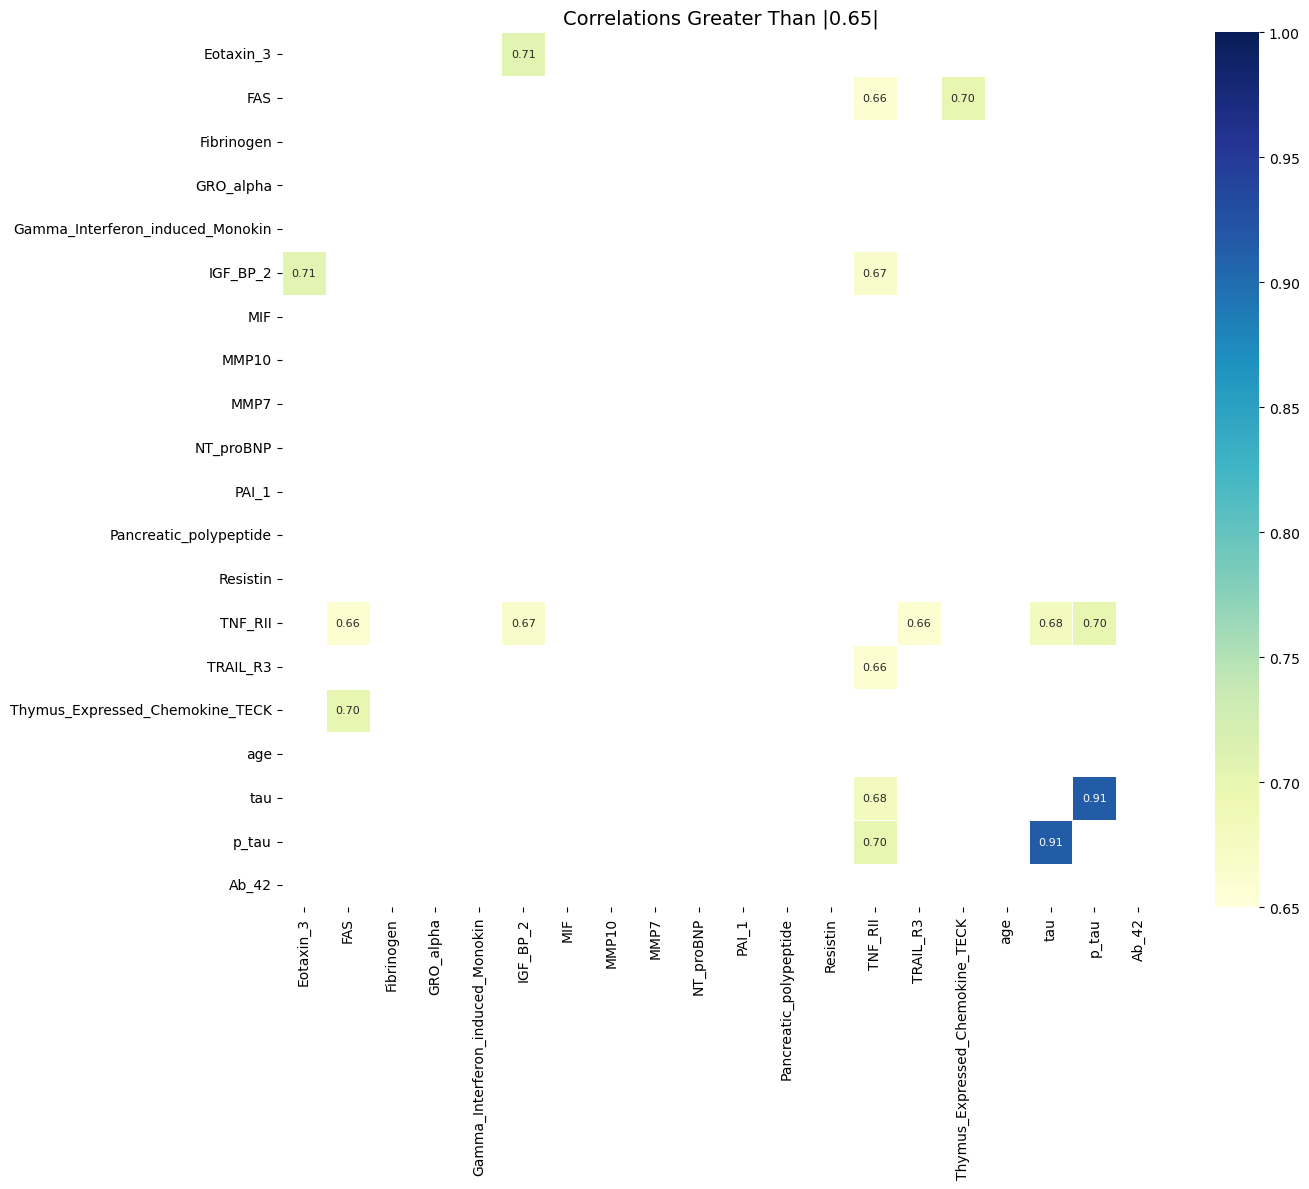

In [36]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.65,        
    vmax=1.0,       
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlations Greater Than |0.65|", fontsize=14)
plt.tight_layout()
plt.show()

The heatmap reveals a few standout relationships that define the data's structure. The strongest link is between tau and p tau, which makes sense given they are closely related Alzheimer’s biomarkers. We also see significant coordination between Eotaxin 3 and Thymus Expressed Chemokine TECK, as well as FAS and TNF RII, likely due to their shared roles in inflammation and cell signaling. Meanwhile, IGF BP 2 and Eotaxin 3 show a clear inverse relationship.

These correlations are a big deal for model interpretation. When predictors are redundant, the model gets "confused" about which one is actually driving the results. This leads to unstable coefficients where one variable might steal the statistical credit from another, making individual importance rankings unreliable. In a logistic regression, this creates high standard errors, meaning we can't be entirely sure if the patterns we're seeing are real or just statistical noise.

## Question 2

### Question 2.1

In [37]:
alz['diagnosis'] = alz['diagnosis'].map({'Control': 0, 'Impaired': 1})
print(alz['diagnosis'].value_counts())

diagnosis
0    242
1     91
Name: count, dtype: int64


### Question 2.2

In [38]:
X = alz.drop(columns=['diagnosis'])
y = alz['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

Training set size: (266, 20)
Test set size:     (67, 20)

Training class distribution:
diagnosis
0    193
1     73
Name: count, dtype: int64


### Question 2.3

In [39]:
lr_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=5000))])

### Question 2.4

In [40]:
# 2.4 — Predictions and metrics
y_pred_lr = lr_pipe.predict(X_test)

# 2.4.1 Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm_lr)

# Extract TN, FP, FN, TP from confusion matrix
tn, fp, fn, tp = cm_lr.ravel()

# 2.4.2 Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy:    {acc_lr:.3f}")

# 2.4.3 Sensitivity (Recall for positive class = Impaired)
sens_lr = recall_score(y_test, y_pred_lr)          # pos_label=1 by default
print(f"Sensitivity: {sens_lr:.3f}")

# 2.4.4 Specificity = TN / (TN + FP)
spec_lr = tn / (tn + fp)
print(f"Specificity: {spec_lr:.3f}")

# 2.4.5 Precision
prec_lr = precision_score(y_test, y_pred_lr)
print(f"Precision:   {prec_lr:.3f}")

Confusion Matrix:
[[46  3]
 [ 5 13]]
Accuracy:    0.881
Sensitivity: 0.722
Specificity: 0.939
Precision:   0.812


### Question 2.5

Accuracy doesn't tell the whole story here because the groups are so uneven. With 242 healthy people and only 91 impaired, a model could get 73% accuracy just by guessing "healthy" every time without actually learning anything. While our 88.1% accuracy looks good on paper, the sensitivity is only 72.2%. This means the model misses nearly 28% of the people who actually have impairments. In a doctor's office, missing nearly 3 out of 10 sick patients is a serious problem.

The other numbers show a clearer picture of these trade-offs. The 93.9% specificity shows the model is great at identifying healthy people, and the 81.2% precision means it is usually right when it flags someone as impaired. However, that low sensitivity proves the model is still biased toward the larger healthy group. This is exactly why we need all these metrics to see the full truth rather than just relying on a single high accuracy score.

## Question 3

### Question 3.1

In [42]:
# 3.1 — Same pipeline with class_weight='balanced'
lr_bal_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced')
)

lr_bal_pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=5000))])

### Question 3.2 — Evaluation and comparison

In [10]:
# 3.2 — Metrics for balanced model
y_pred_bal = lr_bal_pipe.predict(X_test)

cm_bal = confusion_matrix(y_test, y_pred_bal)
tn_b, fp_b, fn_b, tp_b = cm_bal.ravel()

print("Balanced Logistic Regression")
print("Confusion Matrix:")
print(cm_bal)
print(f"\nAccuracy:    {accuracy_score(y_test, y_pred_bal):.3f}")
print(f"Sensitivity: {recall_score(y_test, y_pred_bal):.3f}")
print(f"Specificity: {tn_b / (tn_b + fp_b):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred_bal):.3f}")

Balanced Logistic Regression
Confusion Matrix:
[[39 10]
 [ 2 16]]

Accuracy:    0.821
Sensitivity: 0.889
Specificity: 0.796
Precision:   0.615


**Question 3.2 — Comparison and Discussion:**

| Metric | Unbalanced LR (Q2) | Balanced LR (Q3) |
|---|---|---|
| Accuracy | 0.881 | 0.821 |
| Sensitivity | 0.722 | 0.889 |
| Specificity | 0.939 | 0.796 |
| Precision | 0.812 | 0.615 |

The balanced model sacrifices some overall accuracy (88.1% → 82.1%) and specificity (93.9% → 79.6%) but gains substantially in sensitivity (72.2% → 88.9%). This is exactly the intended trade-off.

The reason the default model struggles here is that the dataset is imbalanced, there are more Control cases than Impaired ones. Because logistic regression tries to minimize overall loss, it naturally leans toward predicting the majority class (Control) more often, since that's the "safer" bet most of the time. As a result, it tends to miss Impaired patients.

Setting class_weight='balanced' fixes this by telling the model to treat misclassifying an Impaired patient as a more costly mistake. Scikit-learn does this by upweighting minority-class observations based on their frequency in the data, which pushes the decision boundary so the model becomes more likely to predict Impaired when in doubt. The downside is more false positives among Control patients, hence the drop in specificity.

In a clinical setting, this trade-off makes sense. Missing a patient who is actually cognitively impaired is a much more serious error than flagging a healthy patient for follow-up. So even though the balanced model is less accurate overall, it is the more appropriate choice when the cost of a false negative is high.

## Question 4

### Question 4.1

In [11]:
# 4.1 — Extract coefficients from the balanced LR model in the pipeline
lr_bal_model = lr_bal_pipe.named_steps['logisticregression']
coef_series = pd.Series(
    lr_bal_model.coef_[0],
    index=X_train.columns
).sort_values()

print("All coefficients (sorted):")
print(coef_series.to_string())

All coefficients (sorted):
TNF_RII                            -1.158362
Ab_42                              -0.870339
p_tau                              -0.696452
age                                -0.433794
MIF                                -0.228948
IGF_BP_2                           -0.112660
Resistin                           -0.067910
MMP10                              -0.005805
Fibrinogen                         -0.002406
Thymus_Expressed_Chemokine_TECK     0.117841
MMP7                                0.129871
GRO_alpha                           0.211420
Eotaxin_3                           0.286294
PAI_1                               0.322769
FAS                                 0.408506
Pancreatic_polypeptide              0.439699
Gamma_Interferon_induced_Monokin    0.440473
TRAIL_R3                            0.457481
NT_proBNP                           0.529939
tau                                 1.692443


### Question 4.2

In [43]:
# 4.2 — Top 3 and bottom 3 by absolute value
abs_coef = coef_series.abs().sort_values(ascending=False)

print("Top 3 predictors by absolute magnitude:")
print(abs_coef.head(3).to_string())

print("\nBottom 3 predictors by absolute magnitude:")
print(abs_coef.tail(3).to_string())

Top 3 predictors by absolute magnitude:
tau        1.692443
TNF_RII    1.158362
Ab_42      0.870339

Bottom 3 predictors by absolute magnitude:
Resistin      0.067910
MMP10         0.005805
Fibrinogen    0.002406


### Question 4.3

After standardization, all predictors are placed on the same scale, which allows their coefficients to be compared directly in terms of magnitude. A larger absolute coefficient indicates that a one-standard-deviation change in that predictor has a stronger effect on the predicted log-odds of being Impaired.

This property is useful for feature selection. Predictors with coefficients near zero, such as Fibrinogen (0.002), MMP10 (0.006), and Resistin (0.068), contribute almost nothing to the model and could be removed without meaningfully affecting performance. In contrast, tau (1.692), TNF_RII (1.158), and Ab_42 (0.870) carry the most predictive signal and should be retained in any reduced model.

### Question 4.4

A notable finding is that tau has a large positive coefficient (+1.692) while p_tau carries a negative coefficient (−0.696), which appears counterintuitive given that both variables measure related biological processes and are highly correlated with one another (r ≈ 0.91 from Q1).

This pattern is primarily explained by multicollinearity. When two predictors share a high degree of correlation, logistic regression has difficulty isolating the independent contribution of each one. As a result, the model may assign a large positive weight to one predictor and a compensating negative weight to the other, even though the combined effect of the pair still reflects the correct biological relationship with the outcome.

It is also important to remember that in multiple logistic regression, each coefficient represents the effect of a predictor after controlling for all other variables in the model. The coefficient for p_tau therefore reflects only the marginal contribution of p_tau beyond what tau already explains, which can be negative even if p_tau alone is positively associated with cognitive impairment. This is a well-recognized limitation of logistic regression when highly correlated biomarkers are included together, as the individual coefficients become difficult to interpret in isolation even when the overall model predicts well.

## Question 5

### Question 5.1

In [13]:
# 5.1 — SelectKBest with f_classif on training data
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

SelectKBest(k='all')

### Question 5.2

In [44]:
# 5.2 — Ranked predictor scores
scores = pd.Series(
    selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

print("Predictors ranked by f_classif score:")
print(scores.to_string())

print("\nTop 3 predictors:")
top3 = scores.head(3)
print(top3.to_string())

Predictors ranked by f_classif score:
tau                                 59.841648
Ab_42                               42.857782
p_tau                               33.454880
GRO_alpha                           27.540198
NT_proBNP                           24.195066
MMP10                               22.430877
TRAIL_R3                            21.369251
Pancreatic_polypeptide              20.138457
FAS                                 19.515765
MIF                                 17.803136
PAI_1                               16.610235
MMP7                                12.428135
Eotaxin_3                           12.182655
IGF_BP_2                            11.815916
Gamma_Interferon_induced_Monokin    11.735478
Resistin                            11.261767
TNF_RII                             10.682065
Fibrinogen                          10.653519
Thymus_Expressed_Chemokine_TECK      9.846045
age                                  9.148141

Top 3 predictors:
tau      59.841648
Ab_4

### Question 5.3

In [15]:
# 5.3 — Fit balanced LR using only tau, Ab_42, p_tau
top3_features = top3.index.tolist()   # ['tau', 'Ab_42', 'p_tau']

X_train_top3 = X_train[top3_features]
X_test_top3  = X_test[top3_features]

lr_top3_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced')
)
lr_top3_pipe.fit(X_train_top3, y_train)
y_pred_top3 = lr_top3_pipe.predict(X_test_top3)

cm_top3 = confusion_matrix(y_test, y_pred_top3)
tn_t, fp_t, fn_t, tp_t = cm_top3.ravel()

print("Confusion Matrix:")
print(cm_top3)
print(f"\nAccuracy:             {accuracy_score(y_test, y_pred_top3):.3f}")
print(f"Sensitivity (Recall): {recall_score(y_test, y_pred_top3):.3f}")
print(f"Specificity:          {tn_t / (tn_t + fp_t):.3f}")
print(f"Precision:            {precision_score(y_test, y_pred_top3):.3f}")

Confusion Matrix:
[[40  9]
 [ 4 14]]

Accuracy:             0.806
Sensitivity (Recall): 0.778
Specificity:          0.816
Precision:            0.609


### Question 5.4


| Metric | Balanced LR — All 20 (Q3) | Balanced LR — Top 3 (Q5) |
|---|---|---|
| Accuracy | 0.821 | 0.806 |
| Sensitivity | 0.889 | 0.778 |
| Specificity | 0.796 | 0.816 |
| Precision | 0.615 | 0.609 |

The three-predictor model using tau, Ab_42, and p_tau performs surprisingly well relative to the full model, given that it relies on only 3 of the 20 available predictors. Most performance metrics decline only modestly, with the most notable reduction occurring in sensitivity, which drops from 0.889 to 0.778, indicating that the reduced model misses a greater number of Impaired cases.

This result suggests that these three Alzheimer's-specific biomarkers account for the majority of the discriminative signal present in the dataset, with the remaining 17 predictors contributing only incremental value. In contexts where cost or simplicity is a practical concern, a three-marker panel could represent a reasonable compromise. However, the reduction in sensitivity carries clinical significance. When the primary objective is to minimize missed Impaired cases, the full model remains the more appropriate choice.

## Question 6

### Question 6.1

In [46]:
# 6.1 — Full Random Forest with balanced class weights
rf_full = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_full.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Question 6.2

In [47]:
# 6.2 — Variable importances sorted descending
importances = pd.Series(
    rf_full.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Random Forest variable importance:")
print(importances.to_string())

Random Forest variable importance:
Ab_42                               0.155699
tau                                 0.132806
MMP10                               0.055509
p_tau                               0.054997
NT_proBNP                           0.051834
Pancreatic_polypeptide              0.048747
MMP7                                0.042068
Eotaxin_3                           0.041090
GRO_alpha                           0.039931
FAS                                 0.039372
Fibrinogen                          0.038447
age                                 0.037481
Gamma_Interferon_induced_Monokin    0.036680
PAI_1                               0.036150
Resistin                            0.034284
IGF_BP_2                            0.032832
TRAIL_R3                            0.031410
TNF_RII                             0.031305
MIF                                 0.031076
Thymus_Expressed_Chemokine_TECK     0.028280


### Question 6.3

In [49]:
# 6.3 — Top 12 features and reduced RF
top12_features = importances.head(12).index.tolist()

print("Top 12 predictors:")
print(importances.head(12).to_string())

X_train_top12 = X_train[top12_features]
X_test_top12  = X_test[top12_features]

rf_top12 = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_top12.fit(X_train_top12, y_train)

Top 12 predictors:
Ab_42                     0.155699
tau                       0.132806
MMP10                     0.055509
p_tau                     0.054997
NT_proBNP                 0.051834
Pancreatic_polypeptide    0.048747
MMP7                      0.042068
Eotaxin_3                 0.041090
GRO_alpha                 0.039931
FAS                       0.039372
Fibrinogen                0.038447
age                       0.037481


RandomForestClassifier(class_weight='balanced', random_state=42)

### Question 6.4

In [50]:
# 6.4 — Metrics for top-12 RF
y_pred_rf12 = rf_top12.predict(X_test_top12)

cm_rf12 = confusion_matrix(y_test, y_pred_rf12)
tn_r, fp_r, fn_r, tp_r = cm_rf12.ravel()

print("Confusion Matrix:")
print(cm_rf12)
print(f"\nAccuracy:    {accuracy_score(y_test, y_pred_rf12):.3f}")
print(f"Sensitivity: {recall_score(y_test, y_pred_rf12):.3f}")
print(f"Specificity: {tn_r / (tn_r + fp_r):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred_rf12):.3f}")

Confusion Matrix:
[[44  5]
 [ 7 11]]

Accuracy:    0.821
Sensitivity: 0.611
Specificity: 0.898
Precision:   0.688


| Metric | Balanced LR — All 20 (Q3) | RF Top 12 (Q6) |
|---|---|---|
| Accuracy | 0.821 | 0.821 |
| Sensitivity | 0.889 | 0.611 |
| Specificity | 0.796 | 0.898 |
| Precision | 0.615 | 0.688 |

The Random Forest model using the top 12 features achieves the same overall accuracy as the balanced logistic regression at 82.1%, but the distribution of errors differs considerably between the two models. The Random Forest exhibits substantially lower sensitivity (0.611 vs. 0.889), meaning it fails to identify a larger proportion of Impaired cases, while compensating with higher specificity (0.898 vs. 0.796) and precision (0.688 vs. 0.615). The model is therefore more conservative in its predictions, tending to favor the majority class even after balanced class weighting is applied.

This behavior may reflect differences in how the two algorithms implement class weighting internally, or it may be a consequence of the way tree-based decision boundaries respond to reweighting compared to linear models. For the clinical goal of detecting cognitive impairment, the balanced logistic regression demonstrates superior performance on the most relevant metric.

### Question 6.5


| Metric | Balanced LR — Top 3 (Q5.3) | RF Top 12 (Q6.4) |
|---|---|---|
| Accuracy | 0.806 | 0.821 |
| Sensitivity | 0.778 | 0.611 |
| Specificity | 0.816 | 0.898 |
| Precision | 0.609 | 0.688 |

This comparison yields perhaps the most meaningful finding of the analysis. The balanced logistic regression using only three predictors outperforms the Random Forest using twelve predictors on sensitivity, the most clinically important metric, achieving 0.778 compared to 0.611. This occurs while remaining competitive on overall accuracy and sacrificing only a modest amount of specificity.

First, model architecture and class weighting strategy can matter more than the number of features included, particularly when the goal is minority-class detection. Second, expanding the feature set does not guarantee improved sensitivity, as the addition of nine predictors to the Random Forest did not translate into better identification of Impaired cases. Third, the strong performance of the three-predictor model further confirms that tau, Ab_42, and p_tau dominate the predictive signal in this dataset. Finally, it is worth noting that the Random Forest and SelectKBest rank these features slightly differently, with the former placing Ab_42 first and tau second, while the univariate F-test ranks tau highest. Both methods agree that these represent the two strongest predictors, but the difference in ordering reflects the distinct ways in which tree-based importance measures and univariate statistical tests quantify relevance.